# Problem Statement: Build a Smart Mutual Fund Advisor

Name - NILADRI GHOSH

Rollno - 27PGAI0033

*On top of the Mutual Funds Report, [sourced](https://www.kaggle.com/datasets/dhavalrupapara/mutual-funds-market-dataset) from Kaggle*

---

## Objective  
Create a Gradio-based AI assistant that recommends a mutual fund investment portfolio based on the user's risk and return preferences. The app uses Retrieval-Augmented Generation (RAG) on a structured Mutual Fund product dataset, generating explainable, structured results.

---

## User App (Essential Features)

### Inputs
- **Investment Needs**: Free-form text input  
  *(e.g., “high return portfolio, only from Aditya Birla fund house”)*
  
### Output
- **Suggestion**: A natural language explanation of what's recommended and why
- **Recommended Mutual Funds**: Structured as a list containing:
  - Scheme Name
  - Fund House
---

## Developer-Facing Advanced Settings

Shown under a collapsible **LLM Settings (Advanced)** section in the UI.

### Model & Generation Settings
- **Model Selector**: *select 2 more open-source / closed-source models*
  - GPT OSS 120B (`gpt-oss-120b`)
- **Temperature Slider**: Adjustable between 0 and 2

These settings allow developers to tune how deterministic or creative the model’s responses are.

---

## Backend Setup

### Vector Store and RAG
- **Embedding Model**: Nomic Embed Text via Ollama, or other model of your choice
- **Vector Database**: ChromaDB, or other vector DB of your choice
- **RAG Workflow**:
  1. Load product catalog using `CSVLoader`
  2. Parse and clean fields into `Document` objects with metadata
  3. Generate embeddings and index documents
  4. Perform similarity search based on user preferences
  5. Use an LLM to generate structured output parsed via `PydanticOutputParser`

# Part 1: Implement the Solution

## Setup

In [2]:
import gradio as gr
import pandas as pd
import os
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_tavily import TavilySearch
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_community.document_loaders import CSVLoader
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAI
from langchain.prompts import ChatPromptTemplate
from langchain.output_parsers import PydanticOutputParser
from langchain.schema.output_parser import OutputParserException
from langchain_core.documents import Document
from pydantic import BaseModel, Field
from uuid import uuid4
from langgraph.graph import START, StateGraph, END
from typing_extensions import List, TypedDict
from langgraph.checkpoint.memory import MemorySaver

In [3]:
## TODO: Load environment variables and API Keys here
import getpass

load_dotenv(dotenv_path=".env", override=True)

## If the key is not in the .env file, ask for it while running
if not os.getenv("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your GROQ API key: ")

## Defining Components

### Chat Model

In [4]:
## Model name map for UI Mapping
model_name_map = {
    "GPT-OSS-120B": "openai/gpt-oss-120b",
    "LLAMA-3.3-70B": "llama-3.3-70b-versatile",
    "DEEPSEEK-R1-70B": "deepseek-r1-distill-llama-70b",
}

model_choices = [
    "GPT-OSS-120B (Groq)",
    "LLAMA-3.3-70B (Groq)",
    "DEEPSEEK-R1-70B (Groq)",
]


In [5]:
## Model Selector
def get_llm(model_choice, temperature):
    if "Groq" in model_choice:
        key = model_choice.split(" ")[0]
        return init_chat_model(model_name_map[key], model_provider="groq", temperature=temperature)
    raise ValueError("Invalid model")


### Embedding Model

In [6]:
## Create embeddings
## Use: OllamaEmbeddings with llama3.2:1b and pull the model beforehand
import httpx
import subprocess
import time


def ensure_ollama_ready():
    try:
        response = httpx.get("http://127.0.0.1:11434/api/tags", timeout=3)
        if response.status_code == 200:
            return
    except Exception:
        pass

    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, start_new_session=True)

    for _ in range(30):
        try:
            response = httpx.get("http://127.0.0.1:11434/api/tags", timeout=3)
            if response.status_code == 200:
                return
        except Exception:
            pass
        time.sleep(1)

    raise RuntimeError("Ollama could not be started. Run 'ollama serve' and 'ollama pull nomic-embed-text' manually.")


ensure_ollama_ready()
subprocess.run(["ollama", "pull", "nomic-embed-text"], check=True, capture_output=True, text=True)
embeddings_model = OllamaEmbeddings(model="nomic-embed-text")


Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\Niladri Ghosh\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\Niladri Ghosh\generative-ai-pgp-ji-2026\.venv\Lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "C:\Users\Niladri Ghosh\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\Niladri Ghosh\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "C:\Users\Niladri Ghosh\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^

### Vector Store

In [7]:
## TODO: Initialize ChromaDB with a persist directory set
persist_directory = "./chroma_mutual_funds"

vector_store = Chroma(
    collection_name="mutual_funds",
    embedding_function=embeddings_model,
    persist_directory=persist_directory,
)

## Load and Preprocess Data

In [8]:
import os
print(os.getcwd())
print([f for f in os.listdir() if f.endswith(".csv")])

c:\Users\Niladri Ghosh\generative-ai-pgp-ji-2026
['mutual_funds_data.csv']


In [9]:
from langchain_community.document_loaders import CSVLoader
from langchain_core.documents import Document

loader = CSVLoader(file_path="mutual_funds_data.csv", source_column="scheme_code")
documents_raw = loader.load()

documents = []
for doc in documents_raw:
    try:
        row_data = dict(
            line.split(":", 1) for line in doc.page_content.split("\n") if ":" in line
        )
        row_data = {k.strip(): v.strip() for k, v in row_data.items()}

        page_text = (
            f"Scheme Name: {row_data.get('scheme_name', '')} | "
            f"Fund House: {row_data.get('fund_house', '')} | "
            f"Scheme Type: {row_data.get('scheme_type', '')} | "
            f"Scheme Category: {row_data.get('scheme_category', '')} | "
            f"Net Asset Value: {row_data.get('net_asset_value', '')} | "
            f"Date: {row_data.get('date', '')}"
        )

        metadata = {
            "scheme_type": row_data.get("scheme_type", ""),
            "scheme_category": row_data.get("scheme_category", ""),
        }

        documents.append(Document(page_content=page_text, metadata=metadata))

    except Exception as e:
        print("Skipping row due to error:", e)

print(len(documents))


35559


In [10]:
len(documents)

35559

In [11]:
print(documents[0].page_content)

Scheme Name: Grindlays Super Saver Income Fund-GSSIF-Half Yearly Dividend | Fund House: Standard Chartered Mutual Fund | Scheme Type: Open Ended Schemes | Scheme Category: Income | Net Asset Value: 10.7205 | Date: 29-05-2008


In [12]:
len(documents)

35559

## Store in Vector DB

In [13]:
## Store in Chroma - 1000 rows only for quicker processing - and make sure to add UUIDs
if not documents:
    raise ValueError("No documents were parsed from the CSV. Check the dataset path and the field format.")

subset = documents[:1000]

## TODO: Add UUIDs
uuids = [str(uuid4()) for _ in range(len(subset))]

## TODO: Add documents  (batched so the Ollama embedding runner doesn't get overloaded)
BATCH_SIZE = 100
for i in range(0, len(subset), BATCH_SIZE):
    vector_store.add_documents(
        documents=subset[i:i + BATCH_SIZE],
        ids=uuids[i:i + BATCH_SIZE],
    )
    print(f"Added {min(i + BATCH_SIZE, len(subset))}/{len(subset)}")

print("Total in collection:", vector_store._collection.count())


Added 100/1000
Added 200/1000
Added 300/1000
Added 400/1000
Added 500/1000
Added 600/1000
Added 700/1000
Added 800/1000
Added 900/1000
Added 1000/1000
Total in collection: 2000


## Initializing for RAG

### Initialize Retriever

In [14]:
## TODO: Initializer Retriever below
retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5},
)


### Define Pydantic Schema

In [15]:
## TODO: Define Pydantic schema with type and description
class MutualFund(BaseModel):
    scheme_name: str = Field(description="The name of the mutual fund scheme")
    fund_house: str = Field(description="The fund house managing the scheme")
    scheme_type: str = Field(description="The type of mutual fund scheme")
    scheme_category: str = Field(description="The category of the mutual fund scheme")

class MutualFundOutput(BaseModel):
    reasoning: str = Field(description="Brief explanation of the recommendation and why it matches the user's preference")
    schemes: List[MutualFund] = Field(description="List of recommended mutual fund schemes")

parser = PydanticOutputParser(pydantic_object=MutualFundOutput)


### Define Prompt

In [16]:
## TODO: Use ChatPromptTemplate.from_template with fields: preferences, context, format_instructions. 
## Make sure no two selected mutual fund schemes fall under the same fund house AND scheme type.

template = ChatPromptTemplate.from_template(
    """
    You are a smart mutual fund advisor.

    User preferences: {preferences}

    Relevant mutual fund information:
    {context}

    Select up to 3 mutual fund schemes that best fit the user's preference. Favor low-risk funds for conservative investors, balanced funds for moderate investors, and growth/equity funds for aggressive investors.

    Important constraints:
    - Ensure no two selected schemes belong to the same fund house and scheme type combination.
    - Prefer funds whose scheme type and category align with the investment preference.
    - Keep the recommendation explainable and grounded in the context.

    {format_instructions}
    """
)


## Creating RAG Pipeline

### Test RAG Pipeline Manually

In [17]:
preference = "I want a low risk investment portfolio."
context_docs = retriever.invoke(preference)
relevant_text = "\n\n".join(doc.page_content for doc in context_docs)
llm = get_llm(model_choices[0], 0.7)
chain = template | llm | parser
input_dict = {
    "preferences": preference,
    "context": relevant_text,
    "format_instructions": parser.get_format_instructions(),
}
output = chain.invoke(input_dict)
output


MutualFundOutput(reasoning='The user prefers a low‑risk investment portfolio. Both recommended schemes are debt‑oriented, which generally offers lower volatility than equity funds. The Franklin India Low Duration Fund focuses on short‑term, high‑quality instruments, making it one of the safest options in the list. The Sundaram Short Term Credit Risk Fund, while still a debt fund, has a slightly higher credit exposure but remains appropriate for a conservative investor seeking modest returns. The two selections come from different fund houses, satisfying the uniqueness constraint.', schemes=[MutualFund(scheme_name='Franklin India Low Duration Fund - Quarterly - IDCW', fund_house='Franklin Templeton Mutual Fund', scheme_type='Open Ended Schemes', scheme_category='Debt Scheme - Low Duration Fund'), MutualFund(scheme_name='Sundaram Short Term Credit Risk Fund -Dividend', fund_house='Sundaram Mutual Fund', scheme_type='Open Ended Schemes', scheme_category='Debt Scheme - Credit Risk Fund')])

### Define RAG Pipeline Function

In [18]:
# RAG pipeline
def generate_portfolio(model_choice, user_input):
    context_docs = retriever.invoke(user_input["preferences"])
    relevant_funds = "\n\n".join(doc.page_content for doc in context_docs)
    llm = get_llm(model_choice, user_input["temperature"])

    #Invoking
    chain = template | llm
    output = chain.invoke({
        "preferences": user_input["preferences"],
        "context": relevant_funds,
        "format_instructions": parser.get_format_instructions(),
    })

    #Exception Handling
    try:
        result = parser.parse(output.content)
    except OutputParserException:
        return "Could not parse output.", None
    return result


## User Interface

In [19]:
def gradio_interface(preferences, model_choice, temperature):
    user_input = {
        "preferences": preferences,
        "model_choice": model_choice,
        "temperature": temperature,
    }
    result = generate_portfolio(model_choice, user_input)
    if not result or isinstance(result, str):
        return result, []
    if isinstance(result, tuple):
        explanation, _ = result
        return explanation, []
    # Build a plain text list of scheme recommendations
    list_output = "\n".join(
        f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
        for scheme in result.schemes
    )

    return result.reasoning, list_output

In [20]:
# Gradio Blocks layout
with gr.Blocks(title="Smart Mutual Fund Advisor", theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        """
        # 💰 Smart Mutual Fund Advisor
        Describe your investment goals in plain English and get an AI-curated portfolio.
        """
    )

    with gr.Row(equal_height=False):
        # ---------------- Left: inputs ----------------
        with gr.Column(scale=1):
            preferences_input = gr.Textbox(
                label="Describe your investment needs",
                placeholder="e.g., high return portfolio, only from Aditya Birla fund house",
                lines=4,
            )

            gr.Examples(
                examples=[
                    "Low risk debt funds for a 3 year horizon",
                    "High return equity portfolio, only from Aditya Birla fund house",
                    "Tax saving ELSS funds with a good track record",
                    "Balanced hybrid funds for a first-time investor",
                ],
                inputs=preferences_input,
                label="Try an example",
            )

            with gr.Accordion("LLM Settings (Advanced)", open=False):
                model_dropdown = gr.Dropdown(
                    label="Model",
                    choices=model_choices,
                    value=model_choices[0],
                )
                temperature_slider = gr.Slider(
                    minimum=0.0, maximum=2, value=0.7, step=0.1,
                    label="Temperature",
                    info="Lower = more focused, higher = more creative",
                )

            with gr.Row():
                clear_button = gr.ClearButton(value="Clear")
                run_button = gr.Button("Generate Portfolio", variant="primary")

        # ---------------- Right: outputs ----------------
        with gr.Column(scale=1):
            reasoning_output = gr.Textbox(
                label="Remarks",
                lines=4,
                show_copy_button=True,
            )
            fund_list_output = gr.Textbox(
                label="Recommended Mutual Funds",
                lines=14,
                show_copy_button=True,
            )

    clear_button.add([preferences_input, reasoning_output, fund_list_output])

    run_button.click(
        fn=gradio_interface,
        inputs=[preferences_input, model_dropdown, temperature_slider],
        outputs=[reasoning_output, fund_list_output],
    )
    # Enter key in the textbox also submits
    preferences_input.submit(
        fn=gradio_interface,
        inputs=[preferences_input, model_dropdown, temperature_slider],
        outputs=[reasoning_output, fund_list_output],
    )

demo.queue()


Gradio Blocks instance: 3 backend functions
-------------------------------------------
fn_index=0
 inputs:
 |-<gradio.components.dataset.Dataset object at 0x0000023355E4CBF0>
 outputs:
 |-<gradio.components.textbox.Textbox object at 0x000002335AA5F560>
fn_index=2
 inputs:
 |-<gradio.components.textbox.Textbox object at 0x000002335AA5F560>
 |-<gradio.components.dropdown.Dropdown object at 0x000002335EE86E10>
 |-<gradio.components.slider.Slider object at 0x000002335EE58380>
 outputs:
 |-<gradio.components.textbox.Textbox object at 0x000002335EE86EA0>
 |-<gradio.components.textbox.Textbox object at 0x000002335A795070>
fn_index=3
 inputs:
 |-<gradio.components.textbox.Textbox object at 0x000002335AA5F560>
 |-<gradio.components.dropdown.Dropdown object at 0x000002335EE86E10>
 |-<gradio.components.slider.Slider object at 0x000002335EE58380>
 outputs:
 |-<gradio.components.textbox.Textbox object at 0x000002335EE86EA0>
 |-<gradio.components.textbox.Textbox object at 0x000002335A795070>

In [21]:
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


# Part 2: Implement the RAG pipeline in LangGraph

## Creating Graph

### Define State Class

In [22]:
## TODO: Define State class with preferences, context and answer keys
class State(TypedDict):
    preferences: str
    context: list
    answer: str


### Define Nodes

In [23]:
## TODO: Define retrieve node
def retrieve(state: State):
    relevant_funds = retriever.invoke(state["preferences"])
    return {"context": relevant_funds}


In [24]:
## TODO: Define generate node
def generate(state: State):
    relevant_funds_str = "\n\n".join(doc.page_content for doc in state["context"])

    llm_graph = get_llm("GPT-OSS-120B (Groq)", 0.7)
    chain = template | llm_graph
    output = chain.invoke({
        "preferences": state["preferences"],
        "context": relevant_funds_str,
        "format_instructions": parser.get_format_instructions(),
    })

    #Exception Handling for Output Parser
    try:
        result = parser.parse(output.content)
    except OutputParserException:
        return {"answer": "Could not parse output."}

    return {"answer": result}


### Build and Compile Graph

In [25]:
## TODO: Build the graph with 2 nodes and 3 edges
graph_builder = StateGraph(State)

graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)


In [26]:
#Compile graph
graph = graph_builder.compile()

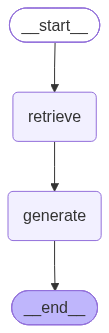

In [27]:
#Visualize graph
display(Image(graph.get_graph().draw_mermaid_png()))

### Test Manually

In [28]:
preferences = "I want a low risk investment portfolio."
llm_graph = get_llm("GPT-OSS-120B (Groq)", 0.7)
result = graph.invoke({"preferences": preferences})
print(f'Context: {result["context"]}\n\n')
print(f'Answer: {result["answer"]}')


Context: [Document(id='94808ba6-3c02-467c-b788-7d4bbf7d6e47', metadata={'scheme_type': 'Open Ended Schemes', 'scheme_category': 'Debt Scheme - Credit Risk Fund'}, page_content='Scheme Name: Sundaram Short Term Credit Risk Fund -Dividend | Fund House: Sundaram Mutual Fund | Scheme Type: Open Ended Schemes | Scheme Category: Debt Scheme - Credit Risk Fund | Net Asset Value: 11.3002 | Date: 29-12-2020'), Document(id='0d6a95f0-c5ce-433f-b82f-eefb0b167aa3', metadata={'scheme_type': 'Open Ended Schemes', 'scheme_category': 'Debt Scheme - Credit Risk Fund'}, page_content='Scheme Name: Sundaram Short Term Credit Risk Fund -Dividend | Fund House: Sundaram Mutual Fund | Scheme Type: Open Ended Schemes | Scheme Category: Debt Scheme - Credit Risk Fund | Net Asset Value: 11.3002 | Date: 29-12-2020'), Document(id='c86ba621-08c1-4192-9440-4653bd015a01', metadata={'scheme_type': 'Open Ended Schemes', 'scheme_category': 'Debt Scheme - Low Duration Fund'}, page_content='Scheme Name: Franklin India Low 

## User Interface

In [29]:
def gradio_interface(preferences, model_choice, temperature):
    user_input = {
        "preferences": preferences,
        "model_choice": model_choice,
        "temperature": temperature,
    }
    llm_graph = get_llm(user_input["model_choice"], user_input["temperature"])
    result = graph.invoke({"preferences": preferences})["answer"]
    
    if not result or isinstance(result, str):
        return result, []
    if isinstance(result, tuple):
        explanation, _ = result
        return explanation, []
    # Build a plain text list of scheme recommendations
    list_output = "\n".join(
        f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
        for scheme in result.schemes
    )

    return result.reasoning, list_output

In [30]:
# ---------------------------------------------------------------------------
# Smart Mutual Fund Advisor — Gradio UI
# ---------------------------------------------------------------------------

APP_TITLE = "Smart Mutual Fund Advisor"
APP_TAGLINE = "AI-assisted mutual fund portfolio recommendations"

EXAMPLE_QUERIES = [
    "High return equity portfolio, only from Aditya Birla fund house",
    "Low risk debt funds for a 3 year horizon",
    "Tax saving ELSS funds with a consistent track record",
    "Balanced hybrid funds suitable for a first-time investor",
]

CUSTOM_CSS = """
#app-header { text-align: center; padding: 8px 0 20px 0; }
#app-header h1 { margin-bottom: 4px; font-weight: 650; }
#app-header p  { margin-top: 0; opacity: 0.7; }
.panel { border-radius: 12px; padding: 16px; }
footer { display: none !important; }
"""

THEME = gr.themes.Soft(
    primary_hue="indigo",
    neutral_hue="slate",
    radius_size=gr.themes.sizes.radius_lg,
)


def build_ui() -> gr.Blocks:
    """Construct and return the Gradio application."""

    with gr.Blocks(title=APP_TITLE, theme=THEME, css=CUSTOM_CSS) as app:

        # ----------------------------- Header -----------------------------
        gr.HTML(
            f"""
            <div id="app-header">
                <h1>{APP_TITLE}</h1>
                <p>{APP_TAGLINE}</p>
            </div>
            """
        )

        # ------------------------- Main workspace -------------------------
        with gr.Row(equal_height=False):

            # ----- Inputs -----
            with gr.Column(scale=4, elem_classes="panel"):
                gr.Markdown("### 1. Your requirements")

                preferences_input = gr.Textbox(
                    label="Investment preferences",
                    placeholder=(
                        "e.g., high return portfolio, only from Aditya Birla fund house"
                    ),
                    lines=4,
                    max_lines=8,
                )

                gr.Examples(
                    examples=EXAMPLE_QUERIES,
                    inputs=preferences_input,
                    label="Sample queries",
                )

                with gr.Accordion("Model settings", open=False):
                    model_dropdown = gr.Dropdown(
                        label="Model",
                        choices=model_choices,
                        value=model_choices[0],
                        interactive=True,
                    )
                    temperature_slider = gr.Slider(
                        label="Temperature",
                        minimum=0.0,
                        maximum=2.0,
                        value=0.7,
                        step=0.1,
                        info="Lower values give more deterministic recommendations.",
                    )

                with gr.Row():
                    clear_button = gr.ClearButton(value="Clear")
                    run_button = gr.Button(
                        "Generate Portfolio", variant="primary", scale=2
                    )

            # ----- Outputs -----
            with gr.Column(scale=6, elem_classes="panel"):
                gr.Markdown("### 2. Recommendation")

                reasoning_output = gr.Textbox(
                    label="Advisor remarks",
                    lines=5,
                    max_lines=10,
                    show_copy_button=True,
                    placeholder="The rationale behind the recommendation appears here.",
                )

                fund_list_output = gr.Textbox(
                    label="Recommended schemes",
                    lines=14,
                    show_copy_button=True,
                    placeholder="Recommended mutual fund schemes appear here.",
                )

        gr.Markdown(
            "<sub>Educational demo only. Not investment advice. "
            "Verify all figures with the official scheme documents.</sub>"
        )

        # ------------------------- Event wiring ---------------------------
        run_event = dict(
            fn=gradio_interface,
            inputs=[preferences_input, model_dropdown, temperature_slider],
            outputs=[reasoning_output, fund_list_output],
        )

        run_button.click(**run_event)
        preferences_input.submit(**run_event)

        clear_button.add(
            [preferences_input, reasoning_output, fund_list_output]
        )

        app.queue(max_size=16)

    return app


demo = build_ui()


In [31]:
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
